# 4. Inversion Examples

This notebook demonstrates end-to-end TEM inversion using pyTEM.
All forward models, Jacobians and inversion utilities are imported directly from the codebase.

Topics covered:
1. **Benchmark model**: three-layer synthetic model used throughout.
2. **Synthetic inversion**: build noisy data from the true model, then recover it using Gauss-Newton inversion.
   - 2.1 Build synthetic data (three square-loop configurations)
   - 2.2 Inversion: correct square forward model vs equivalent-area circle approximation
   - 2.3 Recovery plots: data fit, model comparison, and model difference


In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    invert,
    HAS_NUMBA,
    HAS_CUDA,
)

print(f'Numba: {HAS_NUMBA},  CUDA: {HAS_CUDA}')


Numba: True,  CUDA: True


## 1. Benchmark Model

A simple 3-layer synthetic model is used throughout all examples:

| Layer | Resistivity | Thickness |
|-------|------------|-----------|
| Resistive overburden | 100 Ohm.m | 20 m |
| Conductive target | 10 Ohm.m | 40 m |
| Resistive basement | 500 Ohm.m | half-space |

Data are computed over 31 log-spaced time gates from 10 µs to 10 ms.
Three square-loop configurations are used to span a range of loop sizes and receiver offsets.


In [2]:
# --- True model ---
rho_true    = np.array([100.0, 10.0, 500.0])   # [Ohm.m]
thick_true  = np.array([20.0, 40.0])           # [m]  (2 layers -> 2 thicknesses)

# --- Survey geometry ---
tx_radius   = np.sqrt(40.**2 / np.pi)           # equivalent circular radius for 40 m loop
side_length = 40.0                              # square loop side [m]
rx_offset   = 10.0                              # offset receiver distance [m]

print(f'tx_radius = {tx_radius:.2f} m')
print(f'rho_true  = {rho_true}')
print(f'thick_true = {thick_true}')


tx_radius = 22.57 m
rho_true  = [100.  10. 500.]
thick_true = [20. 40.]


### 2.1 Build synthetic data

Noise-contaminated synthetic data are generated from the true 3-layer model for each of the three square-loop configurations.
Gaussian noise is added as a fraction of the signal amplitude, with a noise floor proportional to $t^{-0.5}$.

| Configuration | Loop size | Rx offset | Noise | Noise floor |
|---|---|---|---|---|
| Large central | 200×200 m | — | 2 % | $10^{-13}\,t^{-0.5}$ |
| Medium central | 50×50 m | — | 2 % | $10^{-13}\,t^{-0.5}$ |
| Small offset | 3×3 m | 10 m | 2 % | $10^{-13}\,t^{-0.5}$ |


200×200 m central: 31 gates  (0.01 ms – 10.0 ms)  noise=2%
50×50 m central: 31 gates  (0.01 ms – 10.0 ms)  noise=2%
3×3 m offset: 31 gates  (0.01 ms – 10.0 ms)  noise=2%

3 configs built in 2.87 s


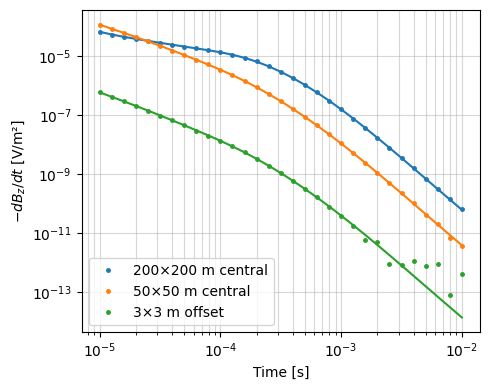

In [3]:
import time

rng = np.random.default_rng(42)

# Each config: (label, L, geom_sq, geom_circ, rx, n_quad,
#               times_inv, noise_frac, noise_floor_amp)
config_specs = [
    ('200×200 m central', 200.0, 'square_central', 'circle_central', None, 5,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
    ('50×50 m central', 50.0, 'square_central', 'circle_central', None, 5,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
    ('3×3 m offset', 3.0, 'square_offset', 'circle_offset', 10.0, 11,
     np.logspace(-5, -2, 31), 0.02, 1e-13),
]

_fwd_kw = dict(transform='dlf', hankel_filter='key_101', fourier_filter='key_81')

t0 = time.perf_counter()
configs = {}
for spec in config_specs:
    label, L, geom_sq, geom_circ, rx, nq, times_inv, noise_frac, noise_floor_amp = spec
    kw = dict(**_fwd_kw)

    if rx is None:
        d_clean = -fwd_square_central(thick_true, rho_true, L, times_inv, n_quad=nq, **kw)
    else:
        d_clean = -fwd_square_offset(thick_true, rho_true, L, rx, 0.0, times_inv, n_quad=nq, **kw)

    L_circ      = L / np.sqrt(np.pi)
    noise_floor = noise_floor_amp * times_inv ** (-0.5)
    noise_std   = np.maximum(noise_frac * np.abs(d_clean), noise_floor)
    d_obs       = d_clean + noise_std * rng.standard_normal(len(d_clean))

    print(f'{label}: {len(times_inv)} gates  '
          f'({times_inv[0]*1e3:.2f} ms – {times_inv[-1]*1e3:.1f} ms)  '
          f'noise={noise_frac*100:.0f}%')
    configs[label] = dict(
        L=L, L_circ=L_circ,
        geom_sq=geom_sq, geom_circ=geom_circ,
        rx=rx, n_quad=nq,
        d_clean=d_clean, times_inv=times_inv,
        d_obs_inv=d_obs, noise_std_inv=noise_std,
    )
print(f'\n3 configs built in {time.perf_counter()-t0:.2f} s')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
for (label, cfg), c in zip(configs.items(), ['C0', 'C1', 'C2']):
    ax.loglog(cfg['times_inv'], np.abs(cfg['d_clean']),   '-', color=c, lw=1.5)
    ax.loglog(cfg['times_inv'], np.abs(cfg['d_obs_inv']), '.', color=c, ms=5, label=label)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$-dB_z/dt$ [V/m²]')
ax.legend()
ax.grid(True, which='both', alpha=0.5)
fig.tight_layout()
plt.show()


### 2.2 Inversion: square vs equivalent-area circle

Each dataset is inverted twice, starting from a homogeneous 10 Ohm.m half-space:

1. **Square forward model** — uses the exact square-loop kernel with Gauss-Legendre quadrature over the loop sides.
2. **Equivalent-area circle** — replaces the square loop with a circle of equal area ($r = L / \sqrt{\pi}$), which requires only a 1-D Hankel transform and is significantly faster.

Using a circular approximation is common in practice because it greatly reduces computation time while introducing only a small systematic bias, particularly for large loops relative to the skin depth. The bias grows as the loop size shrinks relative to the target depth or as the offset geometry becomes more asymmetric.


In [4]:
import time

# Inversion mesh: 15 layers, log-spaced depth axis down to 200 m
n_layers   = 15
depths_inv = np.geomspace(2.0, 200.0, n_layers)
thick_inv  = np.append(np.diff(depths_inv), depths_inv[-1])   # N = 15 elements

# Starting model: homogeneous 100 Ohm.m
rho_start  = np.ones(n_layers) * 10.0
lrho_start = np.log(rho_start)

results_sq   = {}
results_circ = {}
timings      = {}

for label, cfg in configs.items():
    rx_kw = dict(rx_offset=cfg['rx']) if cfg['rx'] is not None else {}
    timings[label] = {}

    common_kw = dict(
        thicknesses       = thick_inv,
        log_resistivities = lrho_start,
        times             = cfg['times_inv'],
        noise_std         = cfg['noise_std_inv'],
        max_noise_frac    = 0.0,
        alpha_start       = None,
        alpha_steps       = 10,
        alpha_step        = 3/9,
        maxit             = 15,
        transform         = 'euler',
        hankel_filter     = 'key_101',
        fourier_filter    = 'key_81',
        use_numba         = HAS_NUMBA,
        use_cuda          = HAS_CUDA,
        calc_sens         = False,
        analytical_j      = True,
        **rx_kw,
    )

    # --- Square inversion (correct geometry) ---
    print(f'[Square]  {label}  (geometry={cfg["geom_sq"]}, L={cfg["L"]:.1f} m) ...')
    t0 = time.perf_counter()
    res = invert(
        obs_data  = cfg['d_obs_inv'],
        tx_radius = cfg['L'],
        geometry  = cfg['geom_sq'],
        n_quad    = cfg['n_quad'],
        **common_kw,
    )
    timings[label]['sq'] = time.perf_counter() - t0
    results_sq[label] = res
    print(f"  Final RMS = {res['rms_history'][-1]:.3f}  ({timings[label]['sq']:.1f} s)\n")

    # --- Circle inversion (equivalent-area approximation) ---
    print(f'[Circle]  {label}  (geometry={cfg["geom_circ"]}, r={cfg["L_circ"]:.2f} m) ...')
    t0 = time.perf_counter()
    res = invert(
        obs_data  = cfg['d_obs_inv'],
        tx_radius = cfg['L_circ'],
        geometry  = cfg['geom_circ'],
        n_quad    = 1,
        **common_kw,
    )
    timings[label]['circ'] = time.perf_counter() - t0
    results_circ[label] = res
    print(f"  Final RMS = {res['rms_history'][-1]:.3f}  ({timings[label]['circ']:.1f} s)\n")

# --- Timing summary ---
print(f"\n{'Config':<22}  {'Square':>10}  {'Iters':>6}  {'Circle':>10}  {'Iters':>6}")
print('-' * 60)
for label in configs:
    n_sq   = len(results_sq[label]['rms_history'])
    n_circ = len(results_circ[label]['rms_history'])
    print(f"{label:<22}  {timings[label]['sq']:>9.1f} s  {n_sq:>6d}  "
          f"{timings[label]['circ']:>9.1f} s  {n_circ:>6d}")


[Square]  200×200 m central  (geometry=square_central, L=200.0 m) ...
Observed data: Mean Apparent Resistivity = 330.6 Ohm.m (over 31/31 valid gates)
Building initial Jacobian...
Alpha start = 1.34e+04
Iteration   1:  RMS = 76.22
    Alpha = 13357.31,  RMS = 21.06
    Alpha = 6199.91,  RMS = 20.04
    Alpha = 2877.74,  RMS = 19.37
    Alpha = 1335.73,  RMS = 19.06
    Alpha = 619.99,  RMS = 19.30
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 19.06
    Alpha = 2877.74,  RMS = 16.58
    Alpha = 1335.73,  RMS = 16.37
    Alpha = 619.99,  RMS = 16.43
    RMS increased - stopping alpha search early.
Iteration   3:  RMS = 16.37
    Alpha = 2877.74,  RMS = 10.73
    Alpha = 1335.73,  RMS = 10.66
    Alpha = 619.99,  RMS = 10.65
    Alpha = 287.77,  RMS = 11.02
    RMS increased - stopping alpha search early.
Iteration   4:  RMS = 10.65
    Alpha = 1335.73,  RMS = 7.74
    Alpha = 619.99,  RMS = 8.02
    RMS increased - stopping alpha search early.
Iteration   5:  RMS 

C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM\pytem\inversion.py:424: RuntimeWarning: invalid value encountered in power
  app_rho = (MU0 / (4 * np.pi * times)) * (term ** (2 / 3))


Alpha start = 1.59e+04
Iteration   1:  RMS = 66.73
    Alpha = 15863.70,  RMS = 24.78
    Alpha = 7363.28,  RMS = 27.38
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 24.78
    Alpha = 34177.32,  RMS = 15.53
    Alpha = 15863.70,  RMS = 11.39
    Alpha = 7363.28,  RMS = 8.91
    Alpha = 3417.73,  RMS = 8.25
    Alpha = 1586.37,  RMS = 8.71
    RMS increased - stopping alpha search early.
Iteration   3:  RMS = 8.25
    Alpha = 7363.28,  RMS = 8.79
    Alpha = 3417.73,  RMS = 5.21
    Alpha = 1586.37,  RMS = 3.15
    Alpha = 736.33,  RMS = 2.25
    Alpha = 341.77,  RMS = 1.84
    Alpha = 158.64,  RMS = 1.62
    Alpha = 73.63,  RMS = 1.66
    RMS increased - stopping alpha search early.
Iteration   4:  RMS = 1.62
    Alpha = 341.77,  RMS = 1.93  (step = 0.25)
    Alpha = 158.64,  RMS = 1.76  (step = 0.25)
    Alpha = 73.63,  RMS = 1.60  (step = 0.25)
    Alpha = 34.18,  RMS = 1.35  (step = 0.50)
    Alpha = 15.86,  RMS = 1.14  (step = 0.50)
    Alpha = 7.36,  RMS =

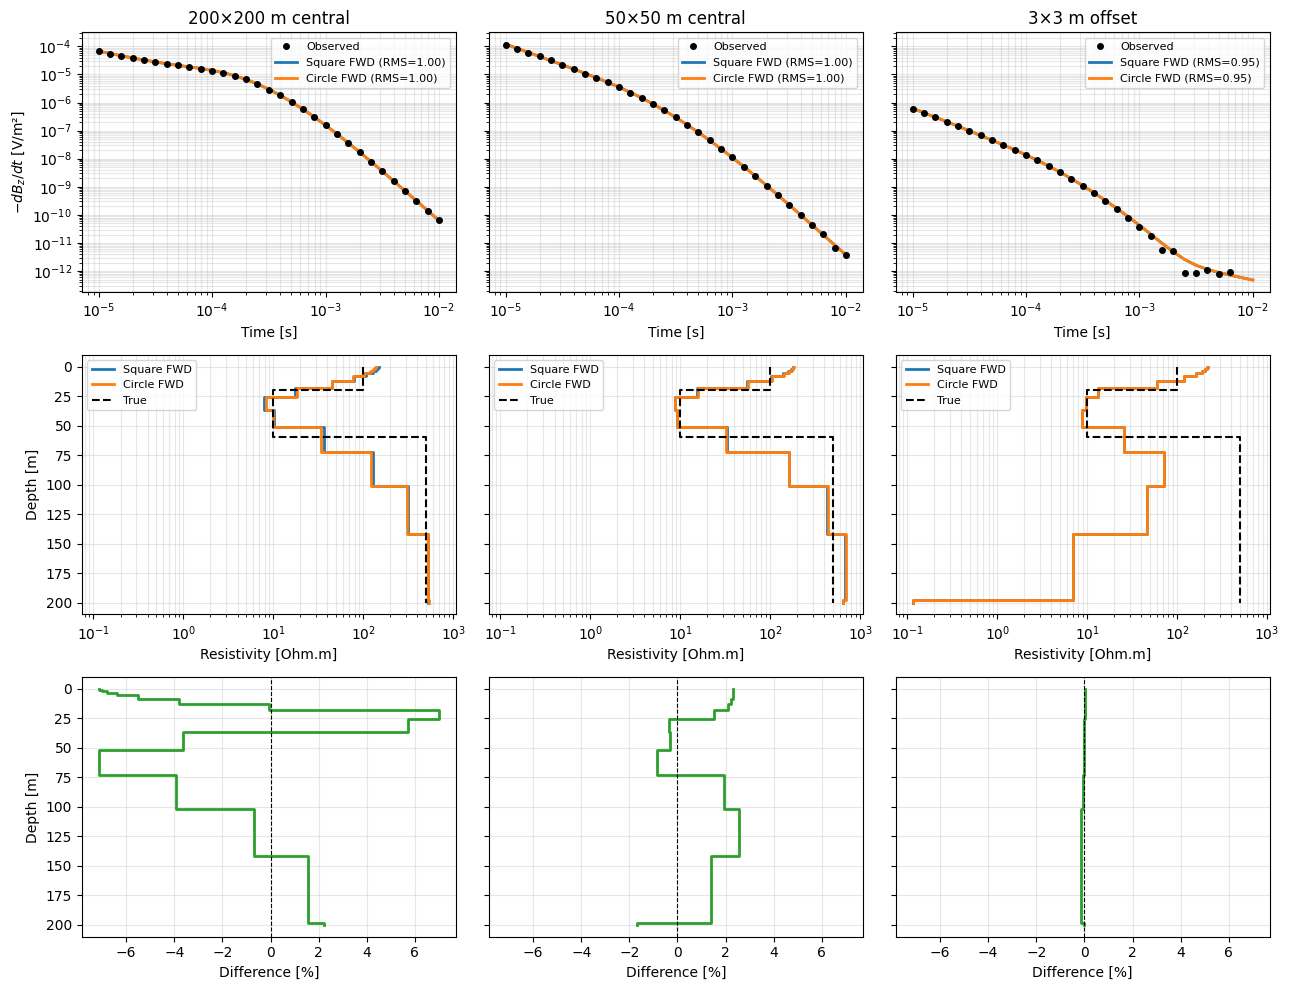

In [5]:

deps_t = np.concatenate(([0], np.cumsum(thick_true), [depths_inv[-1]]))
rho_t  = np.concatenate([np.repeat(rho_true[:-1], 2), [rho_true[-1], rho_true[-1]]])
dep_t  = np.repeat(deps_t, 2)[1:-1]

def make_dpred(cfg, res, geom, L, nq):
    thick_r   = res['thicknesses'][:-1]
    rho_inv   = res['resistivities']
    t         = cfg['times_inv']
    kw        = dict(transform='dlf', hankel_filter='key_101', fourier_filter='key_81')
    if geom == 'circle_central':
        return -fwd_circle_central(thick_r, rho_inv, L, t, **kw)
    elif geom == 'circle_offset':
        return -fwd_circle_offset(thick_r, rho_inv, L, cfg['rx'], t, **kw)
    elif geom == 'square_central':
        return -fwd_square_central(thick_r, rho_inv, L, t, n_quad=nq, **kw)
    else:
        return -fwd_square_offset(thick_r, rho_inv, L, cfg['rx'], 0.0, t, n_quad=nq, **kw)

depth_mids = np.concatenate(([0], np.cumsum(thick_inv[:-1])))

fig, axs = plt.subplots(3, 3, figsize=(13, 10),
                        gridspec_kw={'height_ratios': [1, 1, 1]},
                        sharey='row', sharex='row')

for j, (label, cfg) in enumerate(configs.items()):
    res_sq   = results_sq[label]
    res_circ = results_circ[label]

    inv_times   = cfg['times_inv']
    obs_trimmed = cfg['d_obs_inv']

    d_pred_sq   = make_dpred(cfg, res_sq,   cfg['geom_sq'],   cfg['L'],      cfg['n_quad'])
    d_pred_circ = make_dpred(cfg, res_circ, cfg['geom_circ'], cfg['L_circ'], 1)

    # --- Row 0: Data misfit ---
    ax = axs[0, j]
    ax.loglog(inv_times, obs_trimmed, 'o',  ms=4, color='k',  label='Observed', zorder=3)
    ax.loglog(inv_times, d_pred_sq,   '-',  lw=2, color='C0', label=f"Square FWD (RMS={res_sq['rms_history'][-1]:.2f})")
    ax.loglog(inv_times, d_pred_circ, '-',  lw=2, color='C1', label=f"Circle FWD (RMS={res_circ['rms_history'][-1]:.2f})")
    ax.set_title(label)
    ax.set_xlabel('Time [s]')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

    # --- Row 1: Model recovery ---
    ax = axs[1, j]
    for res, color, tag in [(res_sq, 'C0', 'Square FWD'), (res_circ, 'C1', 'Circle FWD')]:
        thick_r  = res['thicknesses'][:-1]
        rho_inv  = res['resistivities']
        depths_r = np.concatenate(([0], np.cumsum(thick_r)))
        rho_step = np.repeat(rho_inv, 2)
        dep_step = np.repeat(np.append(depths_r, depths_inv[-1]), 2)[1:-1]
        ax.semilogx(rho_step, dep_step, '-', lw=2, color=color, label=tag)
    ax.semilogx(rho_t, dep_t, '--', lw=1.5, color='k', label='True')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('Resistivity [Ohm.m]')

    # --- Row 2: Model difference (%) ---
    rho_sq_inv   = res_sq['resistivities']
    rho_circ_inv = res_circ['resistivities']
    delta_pct    = (rho_circ_inv - rho_sq_inv) / rho_sq_inv * 100.0
    dep_step     = np.repeat(np.append(depth_mids, depths_inv[-1]), 2)[1:-1]
    delta_step   = np.repeat(delta_pct, 2)

    ax = axs[2, j]
    ax.plot(delta_step, dep_step, '-', lw=2, color='C2')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(r'Difference [%]')
    ax.grid(True, which='both', alpha=0.3)

# Invert depth axes once — calling invert_yaxis() inside the column loop
# toggles the shared axis each time (sharey='row'), which flips the result
# when the number of configs is even.
axs[1, 0].invert_yaxis()
axs[2, 0].invert_yaxis()

axs[0, 0].set_ylabel(r'$-dB_z/dt$ [V/m²]')
axs[1, 0].set_ylabel('Depth [m]')
axs[2, 0].set_ylabel('Depth [m]')
fig.tight_layout()
plt.show()


### 2.4 Circle warm-start

For square-loop geometries the forward model is significantly more expensive than the equivalent-area circle (Gauss-Legendre quadrature over the loop sides vs a single Hankel transform).  The `circle_warmstart=True` flag exploits this by:

1. Running the full Gauss-Newton inversion with the circle model until convergence.
2. Taking the converged model as a starting point and doing **one** refinement step with the exact square forward model.

This gives a result very close to a pure square inversion at a fraction of the cost.  The example below runs all three configurations with `circle_warmstart=True` and compares the timing and final RMS against the pure square result.


In [6]:
import time
results_ws = {}
timings_ws = {}

for label, cfg in configs.items():
    if not cfg['geom_sq'].startswith('square'):
        continue
    rx_kw = dict(rx_offset=cfg['rx']) if cfg['rx'] is not None else {}

    t0 = time.perf_counter()
    res = invert(
        obs_data          = cfg['d_obs_inv'],
        thicknesses       = thick_inv,
        log_resistivities = lrho_start,
        tx_radius         = cfg['L'],
        times             = cfg['times_inv'],
        noise_std         = cfg['noise_std_inv'],
        max_noise_frac    = 0.0,
        alpha_start       = None,
        alpha_steps       = 5,
        maxit             = 15,
        transform         = 'euler',
        hankel_filter     = 'key_101',
        fourier_filter    = 'key_81',
        use_numba         = HAS_NUMBA,
        use_cuda          = HAS_CUDA,
        calc_sens         = False,
        analytical_j      = True,
        geometry          = cfg['geom_sq'],
        n_quad            = cfg['n_quad'],
        circle_warmstart  = True,
        **rx_kw,
    )
    timings_ws[label] = time.perf_counter() - t0
    results_ws[label] = res

# --- Comparison table ---
print(f"\n{'Config':<22}  {'Square (pure)':>14}  {'Warm-start':>12}  {'ΔRMS':>8}")
print('-' * 65)
for label in results_ws:
    rms_sq = results_sq[label]['rms_history'][-1]
    rms_ws = results_ws[label]['rms_history'][-1]
    t_sq   = timings[label]['sq']
    t_ws   = timings_ws[label]
    print(f"{label:<22}  {t_sq:>9.1f} s  {rms_sq:>5.3f}  "
          f"{t_ws:>7.1f} s  {rms_ws:>5.3f}  {rms_ws - rms_sq:>+8.4f}")


[circle_warmstart] Running circle pre-inversion (geometry=circle_central, r=112.838 m)...
Observed data: Mean Apparent Resistivity = 154.1 Ohm.m (over 31/31 valid gates)
Building initial Jacobian...
Alpha start = 1.34e+04
Iteration   1:  RMS = 74.81
    Alpha = 13413.27,  RMS = 20.47
    Alpha = 10385.41,  RMS = 19.29
    Alpha = 8041.05,  RMS = 18.15
    Alpha = 6225.89,  RMS = 17.08
    Alpha = 4820.48,  RMS = 16.10
Iteration   2:  RMS = 16.10
    Alpha = 6225.89,  RMS = 10.22
    Alpha = 4820.48,  RMS = 10.03
    Alpha = 3732.32,  RMS = 9.92
    Alpha = 2889.80,  RMS = 9.91
    Alpha = 2237.47,  RMS = 10.00
    RMS increased - stopping alpha search early.
Iteration   3:  RMS = 9.91
    Alpha = 3732.32,  RMS = 6.75
    Alpha = 2889.80,  RMS = 6.13
    Alpha = 2237.47,  RMS = 5.60
    Alpha = 1732.39,  RMS = 5.19
    Alpha = 1341.33,  RMS = 4.93
Iteration   4:  RMS = 4.93
    Alpha = 1732.39,  RMS = 4.82
    Alpha = 1341.33,  RMS = 4.15
    Alpha = 1038.54,  RMS = 3.58
    Alpha = 804

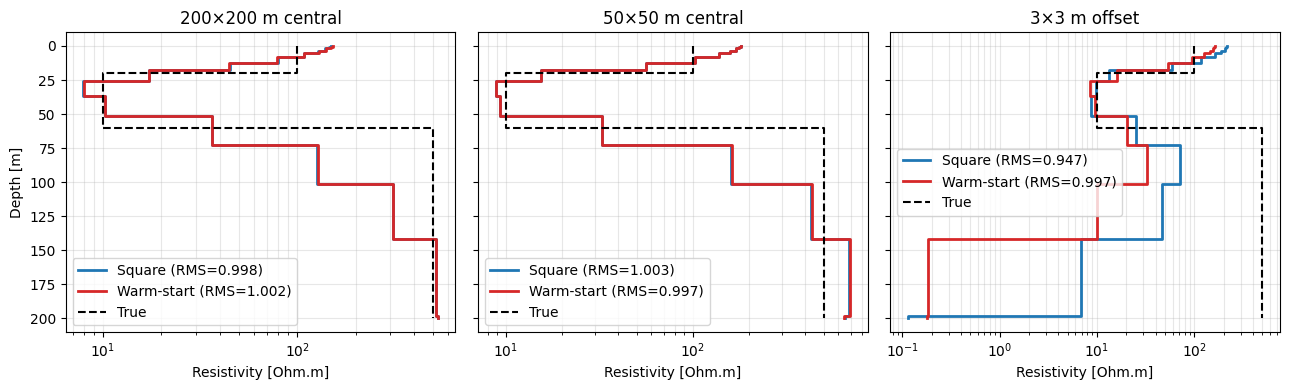

In [7]:
# --- Recovery comparison: pure square vs warm-start ---
fig, axs = plt.subplots(1, len(results_ws), figsize=(13, 4), sharey=True)

for j, (label, cfg) in enumerate([item for item in configs.items()
                                   if item[1]['geom_sq'].startswith('square')]):
    res_sq_pure = results_sq[label]
    res_ws_     = results_ws[label]

    thick_r = res_sq_pure['thicknesses'][:-1]
    depths_r = np.concatenate(([0], np.cumsum(thick_r)))

    ax = axs[j] if len(results_ws) > 1 else axs

    for res, color, tag in [
        (res_sq_pure, 'C0', f"Square (RMS={res_sq_pure['rms_history'][-1]:.3f})"),
        (res_ws_,     'C3', f"Warm-start (RMS={res_ws_['rms_history'][-1]:.3f})"),
    ]:
        rho_inv  = res['resistivities']
        rho_step = np.repeat(rho_inv, 2)
        dep_step = np.repeat(np.append(depths_r, depths_inv[-1]), 2)[1:-1]
        ax.semilogx(rho_step, dep_step, '-', lw=2, color=color, label=tag)

    ax.semilogx(rho_t, dep_t, '--', lw=1.5, color='k', label='True')
    ax.set_title(label)
    ax.set_xlabel('Resistivity [Ohm.m]')
    ax.invert_yaxis()
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

axs[0].set_ylabel('Depth [m]')
fig.tight_layout()
plt.show()